In [1]:
import requests
import nltk
import seaborn as sns
import matplotlib.pyplot as plt
from nltk.probability import FreqDist
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

Чтобы объединить эти инструменты, давайте решим классическую задачу: скачаем текст (requests), посчитаем частоту слов (nltk) и визуализируем результат (seaborn).Для примера возьмем текст «Алисы в Стране чудес» из открытого API.

In [2]:
# 1. Загружаем данные из сети (requests)
url = "https://githubusercontent.com"
# Для примера просто возьмем любой текстовый ответ или имитируем его:
response = requests.get("https://gutenberg.org")
text = response.text[1000:5000] # Берем фрагмент текста

In [3]:
# 2. Обрабатываем текст (nltk)
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\MI\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\MI\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

In [5]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\MI\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


True

In [6]:
import nltk
nltk.download('punkt')      # Основной токенизатор
nltk.download('punkt_tab')  # Новая таблица данных (решает вашу ошибку)
nltk.download('stopwords')  # Список стоп-слов (и, в, на, the, and...)

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\MI\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\MI\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\MI\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [7]:
# Токенизация (разбиение на слова) и очистка
tokens = nltk.word_tokenize(text.lower())
words = [w for w in tokens if w.isalpha()] # убираем знаки препинания
stop_words = set(stopwords.words('english'))
filtered_words = [w for w in words if w not in stop_words]

In [8]:
# Считаем частоту слов
fdist = FreqDist(filtered_words)
common_words = fdist.most_common(10)

In [9]:
# Преобразуем в формат для визуализации
words_list = [word[0] for word in common_words]
counts_list = [word[1] for word in common_words]

C:\Users\MI\AppData\Local\Temp\ipykernel_10652\3246716988.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts_list, y=words_list, palette="viridis")


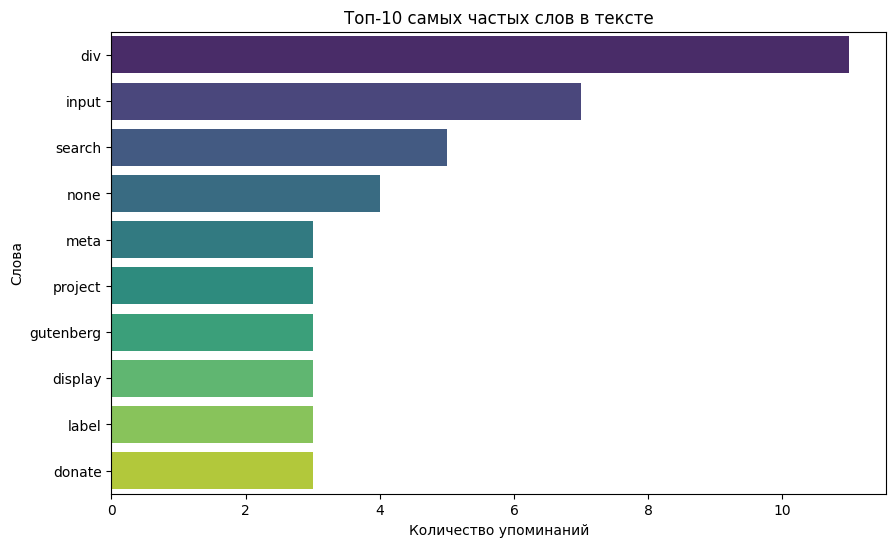

In [10]:
# 3. Визуализируем результат (seaborn)
plt.figure(figsize=(10, 6))
sns.barplot(x=counts_list, y=words_list, palette="viridis")
plt.title("Топ-10 самых частых слов в тексте")
plt.xlabel("Количество упоминаний")
plt.ylabel("Слова")
plt.show()

Для работы с такими крупными сайтами, как Wildberries или Ozon, напрямую через requests часто мешают системы защиты (капчи и блокировки). Поэтому для обучения лучше использовать открытые новостные API (например, NewsAPI) или небольшие новостные сайты.

In [11]:
# 1. Получаем данные (через открытое API или простой новостной сайт)
# Для примера используем RSS-фид или текстовый контент новостного ресурса
url = "https://interfax.ru" # Пример RSS-ленты новостей
response = requests.get(url)
raw_text = response.text

In [12]:
# 2. Очистка и обработка текста (NLTK)
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\MI\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\MI\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [14]:
tokens = nltk.word_tokenize(raw_text.lower())
# Оставляем только русские слова и убираем "мусор" (стоп-слова)
stop_words = set(stopwords.words('russian'))
filtered_words = [w for w in tokens if w.isalpha() and w not in stop_words and len(w) > 3]

In [15]:
# Считаем 15 самых частых слов
freq_dist = nltk.FreqDist(filtered_words)
data = freq_dist.most_common(15)

In [16]:
# Подготовка данных для графика
words = [item[0] for item in data]
counts = [item[1] for item in data]

C:\Users\MI\AppData\Local\Temp\ipykernel_10652\21172782.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=counts, y=words, palette="magma")


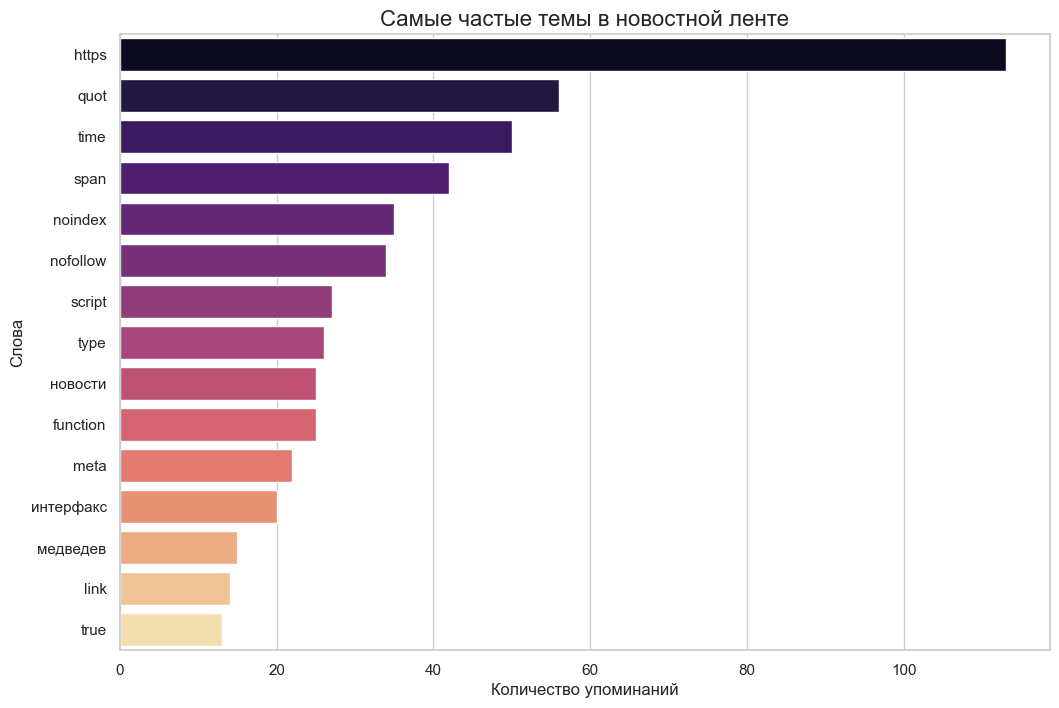

In [17]:
# 3. Визуализация (Seaborn)
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 8))
ax = sns.barplot(x=counts, y=words, palette="magma")

plt.title("Самые частые темы в новостной ленте", fontsize=16)
plt.xlabel("Количество упоминаний", fontsize=12)
plt.ylabel("Слова", fontsize=12)
plt.show()